# GBM: S&P 500 Equity Option Analytics

Regularized linear models topped out at a validation IC of -0.0062 on the 5-day label -
essentially zero and slightly negative. GBM tests whether tree-based models can extract
non-linear interactions among the 48 features (45 IV and equity, 3 GARCH) that a linear
combination missed. The grid searches 5 leaf profiles (7 to 63 leaves) crossed with 3
loss functions (MSE, MAE, Huber) for 15 configurations, each evaluated by cross-sectional
IC at 50-iteration checkpoints.

**Learning Objectives**:
- Test whether non-linear feature interactions rescue signal from 0-FDR features
- Compare regularization profiles and loss functions for IV-enriched equity prediction
- Track IC learning curves to assess overfitting risk with only 2 CV folds
- Generate backtesting-ready predictions for Ch16 strategy simulation

**Book Reference**: Chapter 12, Section 12.2 (GBM Libraries)

**Prerequisites**: `03_financial_features.py` (45 IV + equity features), `04_model_based_features.py` (3 GARCH features)

In [1]:
"""GBM Grid Search - config-driven regularization profiles × loss functions."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml

import utils.style as style
from case_studies.utils.gbm import (
    prepare_gbm_folds,
    register_gbm_result,
    resolve_gbm_execution_config,
    train_gbm_config,
)
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
COLORS = style.COLORS

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Device and histogram resolution are declared independently. Falling back from
# an unavailable accelerator never changes the fitted model's max_bin.
DEVICE, MAX_BIN, NUM_THREADS = resolve_gbm_execution_config(setup["modeling"]["gbm"])

print(f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | max_bin: {MAX_BIN}")

Case study: sp500_equity_option_analytics | Device: cuda | max_bin: 63


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm:` key.
Each config references a preset in `config/lgb/` with the complete
LightGBM parameter set. To modify the grid, edit the label config file.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 527,968 rows × 48 features
Label: fwd_ret_5d | Task: regression | Folds: 2


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")

print(f"\n{len(configs)} configs × {len(splits)} folds\n")
for cfg in configs:
    leaves = cfg["params"].get("num_leaves", 31)
    obj = cfg["params"].get("objective", "regression")
    n_trees = cfg.get("max_iterations", 500)
    print(f"  {cfg['config_name']:25s}  leaves={leaves:3d}  obj={obj}  trees={n_trees}")


15 configs × 2 folds

  default_mse                leaves= 31  obj=regression  trees=500
  default_mae                leaves= 31  obj=regression_l1  trees=500
  default_huber              leaves= 31  obj=huber  trees=500
  leaves_7_mse               leaves=  7  obj=regression  trees=500
  leaves_7_mae               leaves=  7  obj=regression_l1  trees=500
  leaves_7_huber             leaves=  7  obj=huber  trees=500
  leaves_15_mse              leaves= 15  obj=regression  trees=500
  leaves_15_mae              leaves= 15  obj=regression_l1  trees=500
  leaves_15_huber            leaves= 15  obj=huber  trees=500
  leaves_31_mse              leaves= 31  obj=regression  trees=500
  leaves_31_mae              leaves= 31  obj=regression_l1  trees=500
  leaves_31_huber            leaves= 31  obj=huber  trees=500
  leaves_63_mse              leaves= 63  obj=regression  trees=500
  leaves_63_mae              leaves= 63  obj=regression_l1  trees=500
  leaves_63_huber            leaves= 63  obj

## 2. Prepare CV Folds

GBM folds use float32 (LightGBM native precision) and skip
imputation/scaling - gradient boosting handles missing values natively.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    eval_label_col=mds.eval_label_col,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in fold_data:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=209,245  val=103,973
  Fold 1: train=206,126  val=106,766


## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints (every 50 iterations) to
detect overfitting - configs that peak early and decay indicate too much capacity.

In [7]:
def _load_skipped_result(case_study, training_hash, train_dir, cfg, split):
    """Load daily-IC leaderboard fields for an already-complete config."""
    import sqlite3

    db_path = get_case_study_dir(case_study) / "run_log" / "registry.db"
    if not db_path.exists():
        return None
    with sqlite3.connect(str(db_path)) as db:
        row = db.execute(
            """
            SELECT t.elapsed_s, ps.checkpoint_value,
                   COALESCE(pm.ic_mean_daily, pm.ic_mean)
            FROM training_runs t
            JOIN prediction_sets ps ON ps.training_hash = t.training_hash
            LEFT JOIN prediction_metrics pm ON pm.prediction_hash = ps.prediction_hash
            WHERE t.training_hash = ? AND ps.split = ?
              AND ps.created_at >= COALESCE(t.started_at, t.created_at)
            ORDER BY pm.ic_mean_daily DESC NULLS LAST,
                     pm.ic_mean DESC NULLS LAST,
                     ps.checkpoint_value IS NULL
            LIMIT 1
            """,
            (training_hash, split),
        ).fetchone()
    if row is None or row[2] is None:
        return None
    elapsed_s, checkpoint_value, ic_mean = row
    curve_path = train_dir / "learning_curves.parquet"
    learning_curves = pl.read_parquet(curve_path).to_dicts() if curve_path.exists() else []
    return {
        "config_name": cfg["config_name"],
        "best_iter": int(checkpoint_value) if checkpoint_value is not None else None,
        "best_ic": float(ic_mean),
        "elapsed_s": float(elapsed_s or 0.0),
        "learning_curves": learning_curves,
        "checkpoint_ics": {},
        "predictions": [],
        "fold_metrics": {},
        "top_features": [],
        "_skipped": True,
    }

Resolve each config's immutable training hash and current registry state
before deciding whether any compute is necessary.

In [8]:
results = []
pending = []
for cfg in configs:
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=cfg.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        input_lineage=mds.input_lineage,
    )
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    status = training_run_status(CASE_STUDY_ID, spec)
    training_hash = training_hash_from_spec(spec)
    split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash,
        split=PREDICTION_SPLIT,
        current_execution_only=True,
    )
    pending.append((cfg, spec, train_dir, status, training_hash, not split_rows.is_empty()))

Completed hashes contribute their registry-backed daily IC to the
leaderboard. Incomplete states are queued for an explicit retraining pass.

In [9]:
to_train = []
for cfg, spec, train_dir, status, training_hash, split_complete in pending:
    if status.complete and split_complete and not FORCE_RETRAIN:
        print(f"  {cfg['config_name']:25s}  SKIP ({status.summary()}, split={PREDICTION_SPLIT})")
        existing = _load_skipped_result(
            CASE_STUDY_ID, training_hash, train_dir, cfg, PREDICTION_SPLIT
        )
        if existing is not None:
            results.append(existing)
        else:
            print(
                f"  {cfg['config_name']:25s}  SKIP but registry has no "
                f"{PREDICTION_SPLIT} metrics - leaderboard will omit this row"
            )
        continue
    if status.complete and not split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    elif status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {status.summary()}")
    to_train.append((cfg, spec, train_dir, status.exists))

  default_mse                SKIP (complete (hash=12d875632572), split=validation)
  default_mae                SKIP (complete (hash=d1da206fffaa), split=validation)
  default_huber              SKIP (complete (hash=a0478d62f3f7), split=validation)
  leaves_7_mse               SKIP (complete (hash=70fc91e2517d), split=validation)
  leaves_7_mae               SKIP (complete (hash=7f990f21c5e6), split=validation)
  leaves_7_huber             SKIP (complete (hash=d955423e636d), split=validation)
  leaves_15_mse              SKIP (complete (hash=46b8a12b35f0), split=validation)
  leaves_15_mae              SKIP (complete (hash=a2631727c8e4), split=validation)
  leaves_15_huber            SKIP (complete (hash=5b861d9e73cf), split=validation)
  leaves_31_mse              SKIP (complete (hash=66efb60be3ea), split=validation)
  leaves_31_mae              SKIP (complete (hash=61f7ef85d64e), split=validation)
  leaves_31_huber            SKIP (complete (hash=b7853df43087), split=validation)
  le

Training remains incremental: each completed config registers immediately,
so an interrupted grid does not discard earlier work.

In [10]:
for cfg, spec, train_dir, replace_existing in to_train:
    result = train_gbm_config(
        cfg,
        fold_data,
        feature_names=feature_names,
        device=DEVICE,
        num_threads=NUM_THREADS,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    results.append(result)
    print(
        f"  {result['config_name']:25s}  iter={result['best_iter']:4d}  "
        f"IC={result['best_ic']:+.4f}  ({result['elapsed_s']:.0f}s)"
    )
    register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="07_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
        replace_existing=replace_existing,
        runtime_params={"device": DEVICE, "num_threads": NUM_THREADS},
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        eval_col=mds.eval_label_col,
        training_spec=spec,
    )

## 4. Grid Results

All configs are ranked by daily-pooled validation IC. Each registry row carries
the explicit tree checkpoint selected on the combined validation surface.

In [11]:
results.sort(key=lambda r: r["best_ic"], reverse=True)
best = results[0] if results else None

print(f"{'Config':25s}  {'Iter':>5s}  {'IC':>8s}  {'Time':>6s}")
print("-" * 50)
for r in results:
    marker = " *" if r is best else ""
    # A legacy row without an explicit iteration renders '-' rather than '0'.
    iter_s = f"{r['best_iter']:5d}" if r.get("best_iter") is not None else f"{'-':>5s}"
    print(
        f"  {r['config_name']:25s}  {iter_s}  {r['best_ic']:+.4f}  {r['elapsed_s']:5.0f}s{marker}"
    )

if best:
    iter_str = (
        f"@ {best['best_iter']} trees"
        if best.get("best_iter") is not None
        else "(final-iter pred_set)"
    )
    print(f"\nBest: {best['config_name']} {iter_str} (IC={best['best_ic']:+.4f})")

Config                      Iter        IC    Time
--------------------------------------------------
  default_huber                500  +0.0074      0s *
  default_mse                  500  +0.0054      0s
  leaves_63_huber              450  +0.0040      0s
  leaves_15_mae                500  +0.0039      0s
  leaves_31_huber              500  +0.0031      0s
  leaves_7_mae                 500  +0.0029      0s
  leaves_31_mse                500  +0.0027      0s
  default_mae                  500  +0.0024      0s
  leaves_63_mae                450  +0.0020      0s
  leaves_31_mae                200  +0.0016      0s
  leaves_63_mse                500  +0.0013      0s
  leaves_7_huber               100  -0.0002      0s
  leaves_15_huber              500  -0.0005      0s
  leaves_7_mse                 100  -0.0006      0s
  leaves_15_mse                500  -0.0007      0s

Best: default_huber @ 500 trees (IC=+0.0074)


### Validation IC by configuration

The full grid on one axis, sorted by registered validation IC and colored by loss
function. Every bar sits near zero - the *ordering*, not the magnitude, is what
the sweep reveals. Robust losses occupy four of the top five positions, although
the default MSE configuration ranks second.

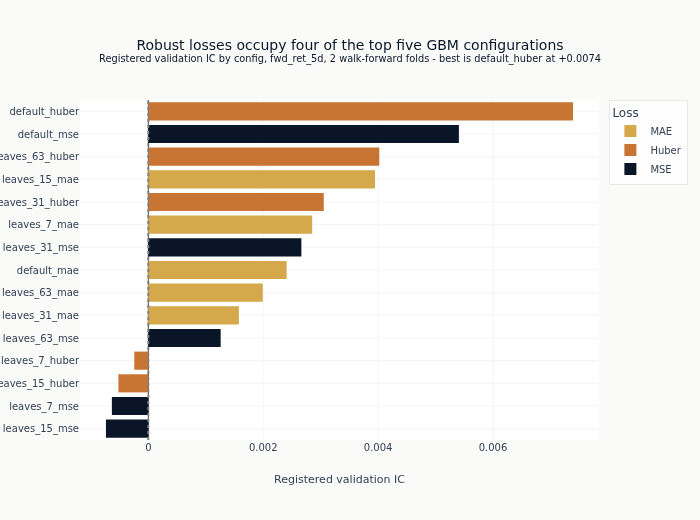

In [12]:
LOSS_COLOR = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}
LOSS_LABEL = {"mse": "MSE", "mae": "MAE", "huber": "Huber"}


def _loss_of(config_name):
    for k in LOSS_COLOR:
        if config_name.endswith(f"_{k}"):
            return k
    return "mse"


order = [r["config_name"] for r in results]  # results is already sorted best-first
fig = go.Figure()
for loss in ("mae", "huber", "mse"):
    rows = [r for r in results if _loss_of(r["config_name"]) == loss]
    fig.add_trace(
        go.Bar(
            y=[r["config_name"] for r in rows],
            x=[r["best_ic"] for r in rows],
            orientation="h",
            name=LOSS_LABEL[loss],
            marker_color=LOSS_COLOR[loss],
        )
    )
fig.add_vline(x=0.0, line=dict(color="gray", dash="dot"))
# categoryarray runs bottom->top, so reverse the best-first order to put the best config on top.
fig.update_yaxes(categoryorder="array", categoryarray=list(reversed(order)))
fig.update_layout(
    title_text="Robust losses occupy four of the top five GBM configurations"
    f"<br><sup>Registered validation IC by config, fwd_ret_5d, 2 walk-forward folds - "
    f"best is {best['config_name']} at {best['best_ic']:+.4f}</sup>",
    xaxis_title="Registered validation IC",
    height=520,
    legend_title_text="Loss",
)
fig.show()

### Loss function vs leaf count

Reshaping the same 15 results as leaf profile against loss function isolates
what drives the ranking. Neither loss nor leaf count dominates by itself: the
default Huber configuration leads, while the 15-leaf MSE configuration trails.
The interaction between capacity and loss matters more than either axis alone.

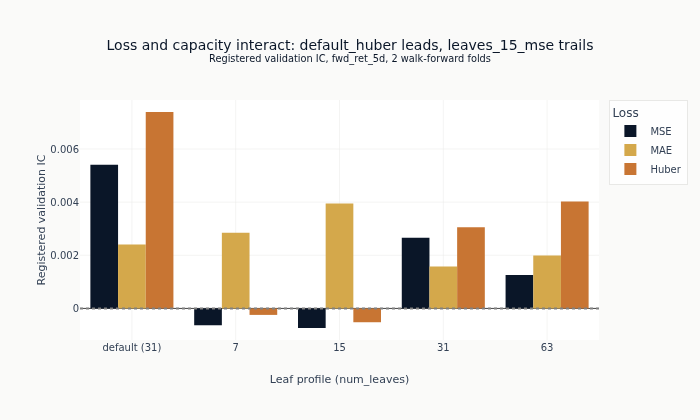

In [13]:
PROFILES = ["default", "leaves_7", "leaves_15", "leaves_31", "leaves_63"]
PROFILE_LABEL = {
    "default": "default (31)",
    "leaves_7": "7",
    "leaves_15": "15",
    "leaves_31": "31",
    "leaves_63": "63",
}
ic_by_config = {r["config_name"]: r["best_ic"] for r in results}
fig2 = go.Figure()
for loss in ("mse", "mae", "huber"):
    fig2.add_trace(
        go.Bar(
            x=[PROFILE_LABEL[p] for p in PROFILES],
            y=[ic_by_config.get(f"{p}_{loss}") for p in PROFILES],
            name=LOSS_LABEL[loss],
            marker_color=LOSS_COLOR[loss],
        )
    )
fig2.add_hline(y=0.0, line=dict(color="gray", dash="dot"))
# Force a categorical x-axis: the numeric-looking labels ("7", "31", ...) would
# otherwise coerce plotly to a linear axis, dropping the non-numeric "default" group.
fig2.update_xaxes(type="category")
fig2.update_layout(
    title_text=f"Loss and capacity interact: {best['config_name']} leads, "
    f"{results[-1]['config_name']} trails<br><sup>Registered validation IC, "
    "fwd_ret_5d, 2 walk-forward folds</sup>",
    xaxis_title="Leaf profile (num_leaves)",
    yaxis_title="Registered validation IC",
    barmode="group",
    height=420,
    legend_title_text="Loss",
)
fig2.show()

## 5. Learning Curves

IC at checkpoints (every 50 iterations) shows whether validation rankings are
stable as trees accumulate. The cached training artifacts retain these curves,
so the reproduction path can inspect checkpoint selection without retraining.

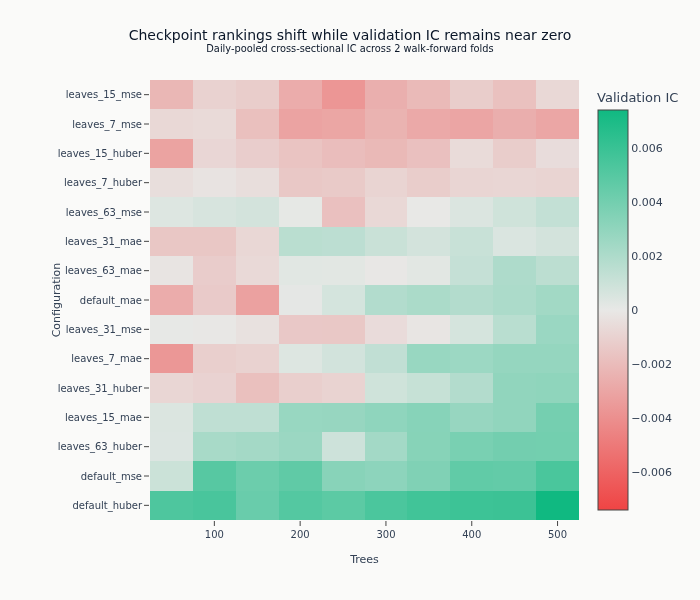

In [14]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
if all_curves.height > 0:
    checkpoints = sorted(all_curves["iteration"].unique().to_list())
    curve_values = []
    for config_name in order:
        config_curve = all_curves.filter(pl.col("config") == config_name)
        by_iteration = dict(zip(config_curve["iteration"], config_curve["ic_mean"], strict=True))
        curve_values.append([by_iteration.get(checkpoint, np.nan) for checkpoint in checkpoints])

    limit = float(np.nanmax(np.abs(curve_values)))
    fig3 = go.Figure(
        go.Heatmap(
            z=curve_values,
            x=checkpoints,
            y=order,
            zmin=-limit,
            zmax=limit,
            zmid=0,
            colorscale=style.ml4t_diverging(),
            colorbar_title="Validation IC",
        )
    )
    fig3.update_layout(
        title_text="Checkpoint rankings shift while validation IC remains near zero"
        "<br><sup>Daily-pooled cross-sectional IC across 2 walk-forward folds</sup>",
        xaxis_title="Trees",
        yaxis_title="Configuration",
        height=600,
        margin=dict(l=150, r=80, t=80, b=80),
    )
    fig3.show()

## 6. Registration Complete

Each config was registered immediately after training (see Section 3).
This protects against interruption - all completed configs are already
persisted in `run_log/registry.db`.

In [15]:
print(f"All {len(results)} configs registered.")

All 15 configs registered.


## 7. Key Takeaways

1. **GBM recovers a marginal signal linear models missed**: the best config
   (`default_huber`, 500 trees) reaches a validation IC of +0.0074, versus the
   regularized-linear ceiling of -0.0062. Non-linear feature interactions flip a negative
   baseline slightly positive, but the effect is tiny in absolute terms.
2. **Robust losses usually rank higher, but not uniformly**: Huber or MAE supplies
   four of the top five configurations, while `default_mse` ranks second. Four of
   the 15 estimates are negative, all between -0.0002 and -0.0007, so the sweep
   supports a weak ranking result rather than a broad claim for one loss family.
3. **Capacity and loss interact**: `default_huber` leads while `leaves_15_mse`
   trails. No leaf count or loss family dominates across every paired setting,
   and the checkpoint heatmap shows that rankings also shift as trees accumulate.
4. **The FDR paradox persists**: none of the 48 features is individually significant
   (Chapter 5 / notebook 05 feature triage), yet GBM extracts a small positive
   cross-sectional IC - weak interaction signal that the univariate screen cannot see.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests whether attention-based tabular models capture
higher-order feature interactions more effectively than tree splits.